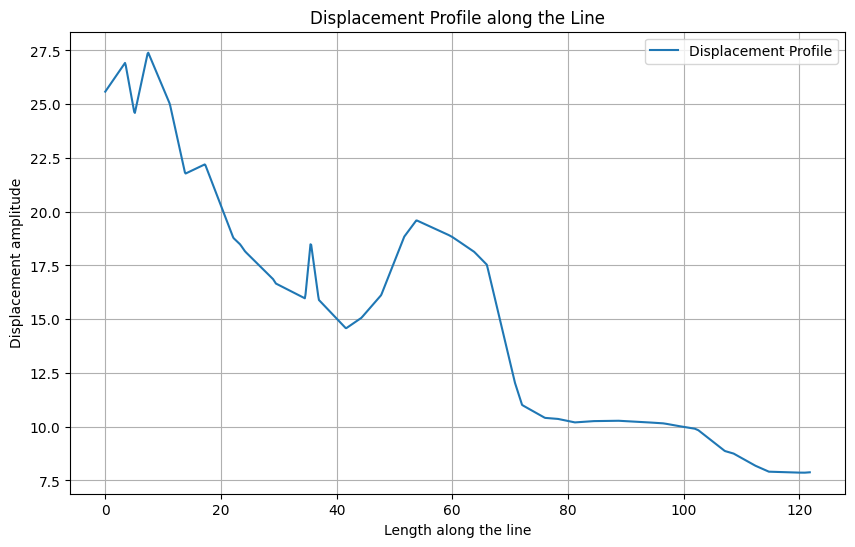

In [3]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os

# Load the CSV file
csv_file_path = '/Users/eugene/Documents/Mice_Output/Cropped/pydic/result/cropped_1000483_result.csv'
data = pd.read_csv(csv_file_path)

# Extract x, y coordinates and displacement
x_coords = data.iloc[:, 0].values
y_coords = data.iloc[:, 1].values
displacements = data.iloc[:, -1].values

# Load the image
image_path = '/Users/eugene/Documents/Mice_Output/Cropped/cropped_1000483.png'
image = cv2.imread(image_path)
image_copy = image.copy()

# Variables to store points
points = []

def draw_line(event, x, y, flags, param):
    global points, image_copy

    if event == cv2.EVENT_LBUTTONDOWN:
        points = [(x, y)]
        image_copy = image.copy()

    elif event == cv2.EVENT_LBUTTONUP:
        points.append((x, y))
        cv2.line(image_copy, points[0], points[1], (0, 0, 255), 2)
        cv2.imshow("Image", image_copy)

    elif event == cv2.EVENT_MOUSEMOVE and len(points) == 1:
        image_copy = image.copy()
        cv2.line(image_copy, points[0], (x, y), (0, 0, 255), 2)
        cv2.imshow("Image", image_copy)

# Display the image and set the callback function
cv2.imshow("Image", image_copy)
cv2.setMouseCallback("Image", draw_line)

while True:
    key = cv2.waitKey(1) & 0xFF
    if key == 13:  # Enter key
        break

cv2.destroyAllWindows()

# Check if two points were selected
if len(points) == 2:
    x1, y1 = points[0]
    x2, y2 = points[1]
    
    # Generate the coordinates along the line drawn
    num_points = 1000
    x_line = np.linspace(x1, x2, num_points)
    y_line = np.linspace(y1, y2, num_points)
    
    # Perform bilinear interpolation
    points_array = np.vstack((x_coords, y_coords)).T
    line_displacements = griddata(points_array, displacements, (x_line, y_line), method='linear')
    
    # Create the output directory if it doesn't exist
    output_dir = '/Users/eugene/Documents/Mice_Output/Cropped/Bilinear_Interpolation_Images'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Plot the displacement profile along the line and save the plot
    plt.figure(figsize=(10, 6))
    plt.plot(np.linspace(0, np.sqrt((x2 - x1)**2 + (y2 - y1)**2), num_points), line_displacements, label='Displacement Profile')
    plt.xlabel('Length along the line')
    plt.ylabel('Displacement amplitude')
    plt.title('Displacement Profile along the Line')
    plt.legend()
    plt.grid(True)
    displacement_profile_path = os.path.join(output_dir, 'displacement_profile.png')
    plt.savefig(displacement_profile_path)
    plt.show()
    
    # Save the image with the line drawn
    image_with_line_path = os.path.join(output_dir, 'image_with_line.png')
    cv2.imwrite(image_with_line_path, image_copy)
else:
    print("Please draw a line by selecting two points.")

